In [1]:
import laspy
import numpy as np
from pyproj import Transformer

in_path  = "/media/b085164/Elements/ECCR/georef_VUX_zone_1/HA/260225_160751_VUX-HA1_pcd.las"
out_path = "/media/b085164/Elements/ECCR/georef_VUX_zone_1/HA/260225_160751_VUX-HA1_pcd_LN02.las"

# LV95 ellipsoïdal → LV95 + hauteurs LN02 (NF02)
transformer = Transformer.from_crs("EPSG:2056", "EPSG:2056+5728", always_xy=True)

las = laspy.read(in_path)
x, y, z = las.x, las.y, las.z

x_out, y_out, z_out = transformer.transform(x, y, z)

las.x = x_out
las.y = y_out
las.z = z_out

las.write(out_path)
print("Done")

Done


In [3]:
las_mls = laspy.read(in_path)
las_als = laspy.read("/home/b085164/PDM_Romain_Defferrard/ECCR/ALS_only/clipped_roi/ECCR_MN95_NF02_2533200-1154700_10xx_only_roi.laz")

print(f"MLS Z median: {np.median(las_mls.z):.3f}")
print(f"ALS Z median: {np.median(las_als.z):.3f}")
print(f"Diff Z: {np.median(las_mls.z) - np.median(las_als.z):.3f} m")

MLS Z median: 463.499
ALS Z median: 412.345
Diff Z: 51.154 m


In [5]:
import laspy
import numpy as np
from pyproj import Transformer
from pathlib import Path

in_path  = "/home/b085164/PDM_Romain_Defferrard/ECCR/ALS_only/clipped_roi/ECCR_MN95_NF02_2533200-1154700_10xx_only_roi.laz"
out_dir  = Path("/home/b085164/PDM_Romain_Defferrard/ECCR/ALS_only/clipped_roi/LV95")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / Path(in_path).name

las_als = laspy.read(in_path)
transformer = Transformer.from_crs("EPSG:2056+5728", "EPSG:2056", always_xy=True)
x_out, y_out, z_out = transformer.transform(las_als.x, las_als.y, las_als.z)

las_als.x = x_out
las_als.y = y_out
las_als.z = z_out

las_als.write(str(out_path))
print(f"Z median après : {np.median(z_out):.3f}")
print(f"Saved → {out_path}")

Z median après : 412.345
Saved → /home/b085164/PDM_Romain_Defferrard/ECCR/ALS_only/clipped_roi/LV95/ECCR_MN95_NF02_2533200-1154700_10xx_only_roi.laz


In [6]:
las_als = laspy.read(in_path)
transformer = Transformer.from_crs("EPSG:2056+5728", "EPSG:2056", always_xy=True)
x_out, y_out, z_out = transformer.transform(las_als.x, las_als.y, las_als.z)

# Forcer les nouveaux offsets
las_als.header.offsets = np.array([x_out.min(), y_out.min(), z_out.min()])
las_als.x = x_out
las_als.y = y_out
las_als.z = z_out

print(f"Z median après : {np.median(z_out):.3f}")
las_als.write(str(out_path))

Z median après : 412.345


In [ ]:
las_als = laspy.read(in_path)

z_shift = 51.154  # diff mesurée tout à l'heure
z_out = np.array(las_als.z) + z_shift

las_als.header.offsets = np.array([
    float(las_als.x.min()),
    float(las_als.y.min()),
    float(z_out.min()),
])

las_als.z = z_out

print(f"Z median après : {np.median(z_out):.3f}")
las_als.write(str(out_path))

Z median après : 463.499


In [8]:
las_als = laspy.read("/home/b085164/PDM_Romain_Defferrard/ECCR/ALS_only/clipped_roi/ECCR_MN95_NF02_2533200-1154700_10xx_only_roi.laz")
print(las_als.header.parse_crs())

PROJCRS["CH1903+ / LV95",BASEGEOGCRS["CH1903+",DATUM["CH1903+",ELLIPSOID["Bessel 1841",6377397.155,299.1528128,LENGTHUNIT["metre",1,ID["EPSG",9001]],ID["EPSG",7004]],ID["EPSG",6150]],ID["EPSG",4150]],CONVERSION["Swiss Oblique Mercator 1995",METHOD["Hotine Oblique Mercator (variant B)",ID["EPSG",9815]],PARAMETER["Latitude of projection centre",46.952405556,ANGLEUNIT["degree",0.0174532925199433,ID["EPSG",9102]]],PARAMETER["Longitude of projection centre",7.439583333,ANGLEUNIT["degree",0.0174532925199433,ID["EPSG",9102]]],PARAMETER["Azimuth of initial line",90,ANGLEUNIT["degree",0.0174532925199433,ID["EPSG",9102]]],PARAMETER["Angle from Rectified to Skew Grid",90,ANGLEUNIT["degree",0.0174532925199433,ID["EPSG",9102]]],PARAMETER["Scale factor on initial line",1,SCALEUNIT["unity",1,ID["EPSG",9201]]],PARAMETER["Easting at projection centre",2600000,LENGTHUNIT["metre",1,ID["EPSG",9001]]],PARAMETER["Northing at projection centre",1200000,LENGTHUNIT["metre",1,ID["EPSG",9001]]],ID["EPSG",19950]]

In [10]:
las_als = laspy.read(in_path)

x_out = np.array(las_als.x) - 16.040001
y_out = np.array(las_als.y) - 12.485992
z_out = np.array(las_als.z) + 49.450012

las_als.header.offsets = np.array([x_out.min(), y_out.min(), z_out.min()])
las_als.x = x_out
las_als.y = y_out
las_als.z = z_out

print(f"Z median après : {np.median(z_out):.3f}")
las_als.write(str(out_path))

Z median après : 461.795


In [13]:
from pyproj import Transformer
import numpy as np

las_als = laspy.read(in_path)

# LV03 → LV95
transformer = Transformer.from_crs("EPSG:21781", "EPSG:2056", always_xy=True)
x_out, y_out, z_out = transformer.transform(las_als.x, las_als.y, las_als.z)

print(f"X avant: {np.median(las_als.x):.3f}  →  après: {np.median(x_out):.3f}")
print(f"Y avant: {np.median(las_als.y):.3f}  →  après: {np.median(y_out):.3f}")
print(f"Z avant: {np.median(las_als.z):.3f}  →  après: {np.median(z_out):.3f}")

X avant: 2533246.268  →  après: 4533246.268
Y avant: 1154640.343  →  après: 2154640.343
Z avant: 412.345  →  après: 412.345


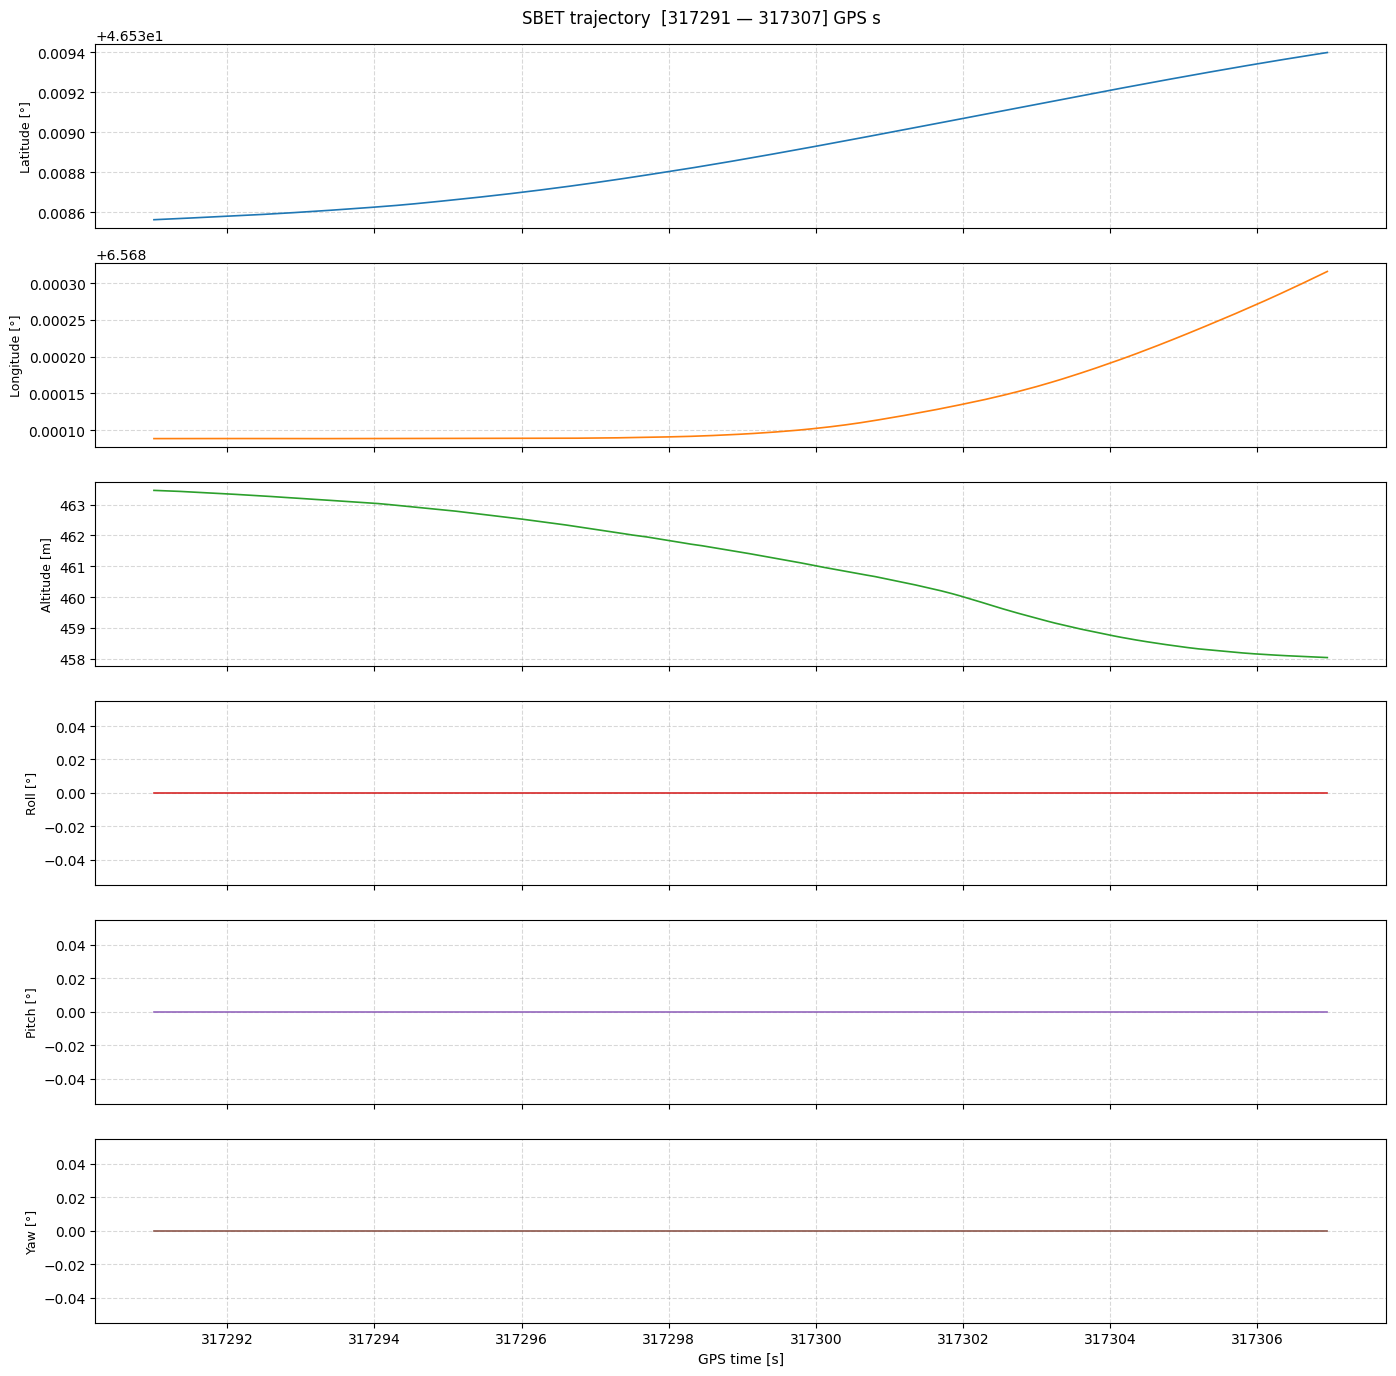

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import struct

def load_sbet(path):
    data = np.fromfile(path, dtype=np.float64).reshape(-1, 17)
    t   = data[:, 0]
    lat = np.degrees(data[:, 1])
    lon = np.degrees(data[:, 2])
    alt = data[:, 3]
    roll  = np.degrees(data[:, 4])
    pitch = np.degrees(data[:, 5])
    yaw   = np.degrees(data[:, 6])
    return t, lat, lon, alt, roll, pitch, yaw

# ============================================================
# Paramètres
# ============================================================
SBET_PATH = "/media/b085164/Elements/ECCR/ODyN/base/out/ODyN_GNSS_INS.out"
T_START   = 317291.0
T_END     = 317307.0

# ============================================================
# Load + clip
# ============================================================
t, lat, lon, alt, roll, pitch, yaw = load_sbet(SBET_PATH)
mask = (t >= T_START) & (t <= T_END)
t_c, lat_c, lon_c, alt_c, roll_c, pitch_c, yaw_c = (
    t[mask], lat[mask], lon[mask], alt[mask],
    roll[mask], pitch[mask], yaw[mask]
)

# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)
fig.suptitle(f"SBET trajectory  [{T_START:.0f} — {T_END:.0f}] GPS s", fontsize=12)

series = [
    (lat_c,   "Latitude [°]",  "#1f77b4"),
    (lon_c,   "Longitude [°]", "#ff7f0e"),
    (alt_c,   "Altitude [m]",  "#2ca02c"),
    (roll_c,  "Roll [°]",      "#d62728"),
    (pitch_c, "Pitch [°]",     "#9467bd"),
    (yaw_c,   "Yaw [°]",       "#8c564b"),
]

for ax, (vals, label, color) in zip(axes, series):
    ax.plot(t_c, vals, color=color, lw=1.2)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(color="grey", ls="--", alpha=0.3)

axes[-1].set_xlabel("GPS time [s]", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
las_mls = laspy.read("/home/b085164/PDM_Romain_Defferrard/ECCR/ALS_only/clipped_roi/ECCR_MN95_NF02_2533200-1154600_10xx_only_roi.laz")
out_dir  = Path("/home/b085164/PDM_Romain_Defferrard/ECCR/ALS_only/clipped_roi/LV95")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "ECCR_MN95_NF02_2533200-1154600_10xx_only_roi.laz"

z_shift = 457.83-407.95  # = +49.88

z_out = np.array(las_mls.z) + z_shift
las_mls.header.offsets[2] = float(z_out.min())
las_mls.z = z_out

las_mls.write(out_path)
print(f"Z median après : {np.median(z_out):.3f}")

Z median après : 462.908


In [ ]:
from pyproj import Transformer
import numpy as np
import pandas as pd

# Load GCPs
gcp = pd.read_csv("/media/b085164/Elements/ECCR/GCP/gcp_LV95_NF02.txt", 
                  sep=r'\s+', header=None, 
                  names=["id", "x", "y", "z_nf02"])

# Transform Z NF02 → ellipsoidal
transformer = Transformer.from_crs("EPSG:2056+5728", "EPSG:4979", always_xy=True)
_, _, z_ellips = transformer.transform(gcp["x"].values, gcp["y"].values, gcp["z_nf02"].values)

gcp["z_ellips"] = z_ellips
print(f"dZ moyen NF02→ellips : {(z_ellips - gcp['z_nf02'].values).mean():.3f} m")
print(gcp[["id","x","y","z_nf02","z_ellips"]].head(10))

# Sauvegarde
out_path = "/media/b085164/Elements/ECCR/GCP/gcp_LV95_ellips.txt"
gcp.to_csv(out_path, sep=" ", index=False, header=True, float_format="%.3f")
print(f"\nSaved → {out_path}")

dZ moyen NF02→ellips : 0.000 m
     id            x            y   z_nf02  z_ellips
0  5001  2532486.559  1154674.604  396.827   396.827
1  5002  2532492.234  1154795.047  401.048   401.048
2  5003  2532580.863  1154648.405  402.203   402.203
3  5004  2532590.329  1154727.228  399.612   399.612
4  5005  2532664.731  1154709.214  399.915   399.915
5  5006  2532749.891  1154676.845  405.967   405.967
6  5007  2532817.420  1154814.995  408.183   408.183
7  5008  2532886.665  1154716.171  407.965   407.965
8  5009  2533053.554  1154776.933  410.102   410.102
9  5010  2533090.840  1154931.816  412.237   412.237

Saved → /media/b085164/Elements/ECCR/GCP/gcp_LV95_ellips.txt


In [28]:
Z_OFFSET = 49.65  # NF02 → ellipsoïdal (empirique, région ECCR)

gcp["z_ellips"] = gcp["z_nf02"] + Z_OFFSET

print(f"Exemple GCP 5008 : NF02={gcp.loc[gcp.id=='5008','z_nf02'].values[0]:.3f} → ellips={gcp.loc[gcp.id=='5008','z_ellips'].values[0]:.3f}")
print(f"Attendu depuis CC : ~457.83")

out_path = "/media/b085164/Elements/ECCR/GCP/gcp_LV95_ellips.txt"
gcp.to_csv(out_path, sep=" ", index=False, header=True, float_format="%.3f")
print(f"Saved → {out_path}")

Exemple GCP 5008 : NF02=407.965 → ellips=457.615
Attendu depuis CC : ~457.83
Saved → /media/b085164/Elements/ECCR/GCP/gcp_LV95_ellips.txt


In [5]:
from rasterio.transform import rowcol

with rasterio.open(GRID_PATH) as src:
    lons, lats, _ = lv95_to_etrs.transform(gcp["x"].values, gcp["y"].values, gcp["z_nf02"].values)
    rows, cols = rowcol(src.transform, lons, lats)
    grid = src.read(1)
    N = grid[np.array(rows), np.array(cols)]

gcp["N"]        = N
gcp["z_ellips"] = gcp["z_nf02"] + N

print(gcp[["id","x","y","z_nf02","N","z_ellips"]].to_string())

out_path = "/media/b085164/Elements/ECCR/GCP/gcp_LV95_ellips.txt"
gcp.to_csv(out_path, sep=" ", index=False, header=True, float_format="%.3f")
print(f"\nSaved → {out_path}")

        id            x            y   z_nf02          N    z_ellips
0     5001  2532486.559  1154674.604  396.827  49.871899  446.698899
1     5002  2532492.234  1154795.047  401.048  49.871899  450.919899
2     5003  2532580.863  1154648.405  402.203  49.871899  452.074899
3     5004  2532590.329  1154727.228  399.612  49.871899  449.483899
4     5005  2532664.731  1154709.214  399.915  49.871899  449.786899
5     5006  2532749.891  1154676.845  405.967  49.871899  455.838899
6     5007  2532817.420  1154814.995  408.183  49.869999  458.052999
7     5008  2532886.665  1154716.171  407.965  49.869999  457.834999
8     5009  2533053.554  1154776.933  410.102  49.869999  459.971999
9     5010  2533090.840  1154931.816  412.237  49.869999  462.106999
10    5011  2533107.185  1154656.000  422.557  49.869999  472.426999
11    5012  2533125.784  1154903.512  412.680  49.869999  462.549999
12    5013  2533155.440  1154704.554  410.048  49.869999  459.917999
13    5014  2533162.464  1154573.2

In [ ]:
import laspy
import numpy as np
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
from pathlib import Path

# ============================================================
# INPUT
# ============================================================
GRID_PATH = "/home/b085164/miniconda3/envs/limatch/lib/python3.9/site-packages/pyproj/proj_dir/share/proj/CH/ch_swisstopo_chgeo2004_ETRS89_LN02.tif"
in_dir    = Path("/home/b085164/PDM_Romain_Defferrard/ECCR/ALS_only/clipped_roi_3")
out_dir   = Path("/home/b085164/PDM_Romain_Defferrard/ECCR/ALS_only/clipped_roi_3/LV95")

out_dir.mkdir(parents=True, exist_ok=True)

CHUNK = 1_000_000

lv95_to_etrs = Transformer.from_crs("EPSG:2056", "EPSG:4258", always_xy=True)

# ============================================================
# FIND FILES
# ============================================================
files = sorted(in_dir.glob("*.laz")) + sorted(in_dir.glob("*.las"))
print(f"{len(files)} fichier(s) trouvé(s)")

# ============================================================
# PROCESS
# ============================================================
with rasterio.open(GRID_PATH) as src:
    grid = src.read(1)

    for laz_path in files:
        out_path = out_dir / laz_path.name
        print(f"\n{'='*60}")
        print(f"  {laz_path.name}")

        las = laspy.read(laz_path)
        x = np.array(las.x)
        y = np.array(las.y)
        z = np.array(las.z)
        print(f"  Z median avant : {np.median(z):.3f}")

        N = np.zeros(len(x), dtype=np.float32)
        for i0 in range(0, len(x), CHUNK):
            i1 = min(i0 + CHUNK, len(x))
            lons, lats, _ = lv95_to_etrs.transform(x[i0:i1], y[i0:i1], z[i0:i1])
            rows, cols = rowcol(src.transform, lons, lats)
            N[i0:i1] = grid[np.array(rows), np.array(cols)]

        z_ellips = z + N.astype(np.float64)
        print(f"  Z median après : {np.median(z_ellips):.3f}")
        print(f"  N moyen        : {N.mean():.3f} m")

        las.header.offsets[2] = float(z_ellips.min())
        las.z = z_ellips
        las.write(out_path)
        print(f"  -> {out_path}")

print("\nTerminé.")

7 fichier(s) trouvé(s)

  ECCR_MN95_NF02_2533100-1155000_10xx_only_roi.laz
  Z median avant : 423.175
  Z median après : 473.045
  N moyen        : 49.870 m
  -> /home/b085164/PDM_Romain_Defferrard/ECCR/ALS_only/clipped_roi_3/LV95/ECCR_MN95_NF02_2533100-1155000_10xx_only_roi.laz

  ECCR_MN95_NF02_2533100-1155100_10xx_only_roi.laz
  Z median avant : 416.548
  Z median après : 466.418
  N moyen        : 49.870 m
  -> /home/b085164/PDM_Romain_Defferrard/ECCR/ALS_only/clipped_roi_3/LV95/ECCR_MN95_NF02_2533100-1155100_10xx_only_roi.laz

  ECCR_MN95_NF02_2533200-1155000_10xx_only_roi.laz
  Z median avant : 419.443
  Z median après : 469.313
  N moyen        : 49.870 m
  -> /home/b085164/PDM_Romain_Defferrard/ECCR/ALS_only/clipped_roi_3/LV95/ECCR_MN95_NF02_2533200-1155000_10xx_only_roi.laz

  ECCR_MN95_NF02_2533200-1155100_10xx_only_roi.laz
  Z median avant : 422.253
  Z median après : 472.123
  N moyen        : 49.870 m
  -> /home/b085164/PDM_Romain_Defferrard/ECCR/ALS_only/clipped_roi_3/LV9